## Лабораторна робота 5. **CLASSIFICATION** 🔵/🔺

Оцінювання даної роботи буде ураховувати якість Ваших висновків та візуалізацій. При наявності ЛИШЕ коду та візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.  

Більшість поставлених в цій лабораторній роботі задач в майбутньому буде ставитись Вами самойстійно!

Під час виконання Вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Оформлення коментарів повинно проводитися в текстових комірках ноутбука з використанням синтаксису [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Basics) для оформлення тексту та формул.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

# Опис вибірки "bank-additional-full"

   # Input variables:
   `bank client data:`  
   1 - **age** (numeric)  
   2 - **job** : type of job (categorical: "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown")  
   3 - **marital** : marital status (categorical: "divorced","married","single","unknown"; note: "divorced" means divorced or widowed)  
   4 - **education** (categorical: "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown")  
   5 - **default**: has credit in default? (categorical: "no","yes","unknown")  
   6 - **housing**: has housing loan? (categorical: "no","yes","unknown")  
   7 - **loan**: has personal loan? (categorical: "no","yes","unknown")  
   # related with the last contact of the current campaign:  
   8 - **contact**: contact communication type (categorical: "cellular","telephone")   
   9 - **month**: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  10 - **day_of_week**: last contact day of the week (categorical: "mon","tue","wed","thu","fri")  
  11 - **duration**: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.  
   # other attributes:  
  12 - **campaign**: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  13 - **pdays**: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)  
  14 - **previous**: number of contacts performed before this campaign and for this client (numeric)
  15 - **poutcome**: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")  
   # social and economic context attributes  
  16 - **emp.var.rate**: employment variation rate - quarterly indicator (numeric)  
  17 - **cons.price.idx**: consumer price index - monthly indicator (numeric)       
  18 - **cons.conf.idx**: consumer confidence index - monthly indicator (numeric)       
  19 - **euribor3m**: euribor 3 month rate - daily indicator (numeric)  
  20 - **nr.employed**: number of employees - quarterly indicator (numeric)  
    
   `Output variable (desired target):`  
  21 - **y** - has the client subscribed a term deposit? (binary: "yes","no")

## Імпорт необхідних бібліотек та завантаження даних

**Завдання 1** підготовка даних до опрацювання

1. завантажте вибірку `bank-additional-full.csv`;   
2. підключіть необхідні бібліотеки;  
3. вивести основну статистичну інформацію по числовим змінним;  
4. вивести розмірність датасету.

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [173]:
df = pd.read_csv("/content/sample_data/bank-additional-full.csv", sep=';')
print(df)
print(df.shape)

       age          job  marital            education  default housing loan  \
0       56    housemaid  married             basic.4y       no      no   no   
1       57     services  married          high.school  unknown      no   no   
2       37     services  married          high.school       no     yes   no   
3       40       admin.  married             basic.6y       no      no   no   
4       56     services  married          high.school       no      no  yes   
...    ...          ...      ...                  ...      ...     ...  ...   
41183   73      retired  married  professional.course       no     yes   no   
41184   46  blue-collar  married  professional.course       no      no   no   
41185   56      retired  married    university.degree       no     yes   no   
41186   44   technician  married  professional.course       no      no   no   
41187   74      retired  married  professional.course       no     yes   no   

         contact month day_of_week  ...  campaign  

**Завдання 2** підготовка цільової змінної  

1. проаналізувати атрибути вибірки, визначити цільовий атрибут `target atribute`;
2. якщо `target atribute` є категоріальним, його необхідно перетворити в чисельний.

In [174]:
df.columns = df.columns.str.strip()

print("Стовпці:", df.columns)

target_col = "target" if "target" in df.columns else df.columns[-1]

if df[target_col].dtype == "object":
    print("Target категоріальний")
    df[target_col] = df[target_col].astype("category").cat.codes

print(df.head())

Стовпці: Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')
Target категоріальний
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  no

## Аналіз змінних, які характеризують клієнтів банку:

**Завдання 3** Визначитись зі всіма атрибутами, що характреризують кліентів банку:
- виділити їх в окрему частину;
- первірити всі змінні (які унікальні значення містять атрибути)(дивись опис датасету).

In [175]:
clients = df[["age", "job", "marital", "education", "default", "loan", "housing"]]
clients.head()

,age,job,marital,education,default,loan,housing
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,no,yes
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,yes,no


In [176]:
clients["job"].value_counts()

,count
job,
admin.,10422
blue-collar,9254
technician,6743
services,3969
management,2924
retired,1720
entrepreneur,1456
self-employed,1421
housemaid,1060


In [177]:
clients["marital"].value_counts()

,count
marital,
married,24928
single,11568
divorced,4612
unknown,80


In [178]:
clients["education"].value_counts()

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
unknown,1731
illiterate,18


In [179]:
clients["default"].value_counts()

,count
default,
no,32588
unknown,8597
yes,3


In [180]:
clients["loan"].value_counts()

,count
loan,
no,33950
yes,6248
unknown,990


In [181]:
clients["housing"].value_counts()

,count
housing,
yes,21576
no,18622
unknown,990


**Завдання 4** Аналіз атрибуту `Age`:  
1. Вивести максимальне та мінімальне значення;  
2. Перевірити на наявність `NaN`;  
3. Провести візуальний аналіз зміної `Age`:
    - побудувати `countplot`, `boxplot`, `distplot`;
    - перевірити розподіл по змінній `Age` на важкі хвости.

Max Age: 98
Min Age: 17
NaN Count: 0


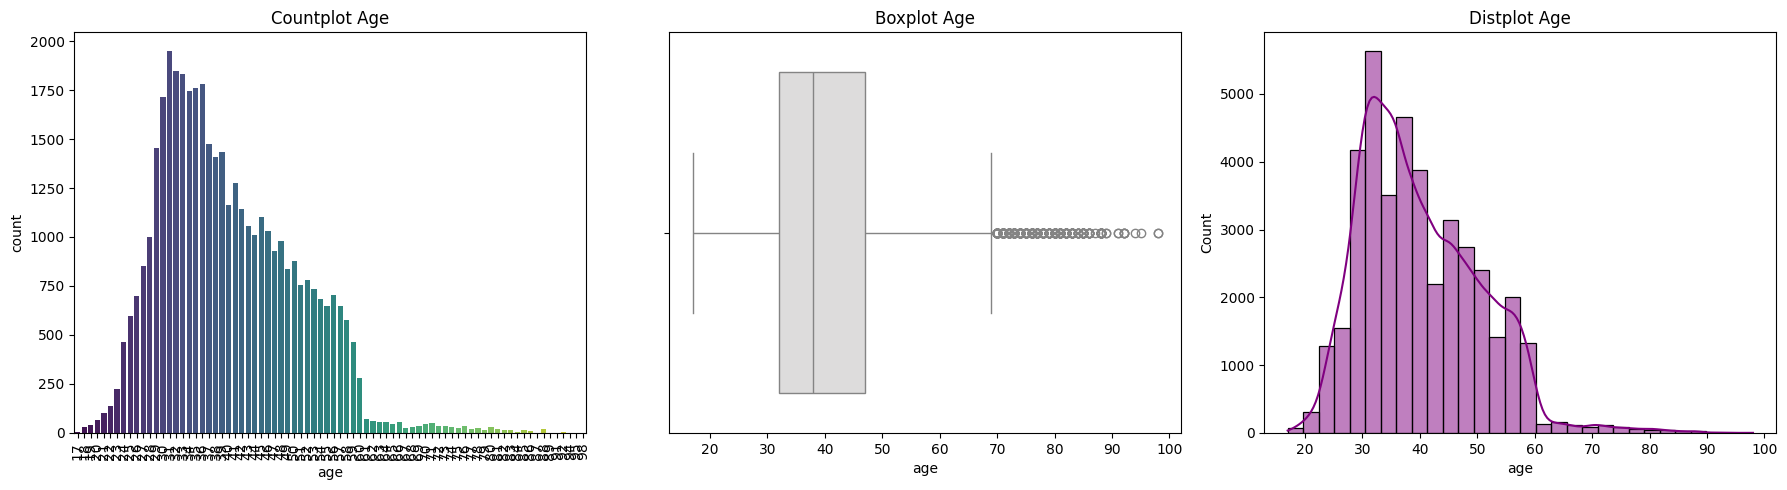

Кількість викидів (важких хвостів): 469


In [40]:
df.columns = df.columns.str.strip().str.lower()

max_age = df["age"].max()
min_age = df["age"].min()
nan_count = df["age"].isna().sum()

print(f"Max Age: {max_age}")
print(f"Min Age: {min_age}")
print(f"NaN Count: {nan_count}")

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x=df["age"], palette="viridis")
plt.xticks(rotation=90)
plt.title("Countplot Age")

plt.subplot(1, 3, 2)
sns.boxplot(x=df["age"], palette="coolwarm")
plt.title("Boxplot Age")

plt.subplot(1, 3, 3)
sns.histplot(df["age"], kde=True, bins=30, color="purple")
plt.title("Distplot Age")

plt.tight_layout()
plt.show()

q1 = df["age"].quantile(0.25)
q3 = df["age"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["age"] < lower_bound) | (df["age"] > upper_bound)]
print(f"Кількість викидів (важких хвостів): {len(outliers)}")


**Висновки з 1-4 завдання (детальні)**

1. Отримали розмірність датасету за допомогою df.shape. Отримали [41188 rows x 21 columns]

2. Проаналізували атрибути вибірки, перетворили target atribute в чисельний.

3. Виділили в окрему частину всі атрибути які характеризують всіх клеєнтів банку. Первірили всі змінні, отримали унікальні атрибути: Атрибути клієнтів: Index([], dtype='object')

4. Вивели min та max age разом з перевіркою на NaN, також побудували графіки countplot, boxplot, distplot. Важкі хвости отримали - Кількість викидів (важких хвостів): 469

**Завдання 5** Перевірити атрибут `Age` на викиди:

In [37]:
def detect_outliers_with_interquantile_range(df: pd.DataFrame,
                                             column: str,
                                             low_percentile: int,
                                             high_percentile: int) -> pd.DataFrame:
    """
    Detecting outliers using interquantile range set manually

    df: pd.DataFrame to detect outliers
    column: target column
    low_percentile: lower bound between 0 and 100
    high_percentile: upper bound between 0 and 100

    returns: pd.DataFrame with detected outliers

    """

    sorted_data = np.sort(df[column])
    # Calculate Q1, Q2, Q3 and IQR.
    Q1 = np.percentile(sorted_data, low_percentile)
    Q3 = np.percentile(sorted_data, high_percentile)
    print('')
    print(f"Q1 {low_percentile} percentile of the given data: {Q1}")
    print('')
    print(f"Q3 {high_percentile} percentile of the given data: {Q3}")
    print('')
    print('----------------------------------------------------------')

    IQR = Q3 - Q1
    print('')
    print(f"Interquantile range: {IQR}")
    print('')
    print('----------------------------------------------------------')
    low_lim = Q1 - 1.5 * IQR
    up_lim = Q3 + 1.5 * IQR
    print('')
    print(f" Lower bound: {low_lim}")
    print('')
    print(f" Upper bound: {up_lim}")
    print('')
    print('----------------------------------------------------------')
    outliers = df[(df[column] > up_lim) | (df[column] < low_lim)]
    print('')
    print(f"Outliers in the dataset:")
    display(outliers)


    return outliers

In [36]:
outliers = detect_outliers_with_interquantile_range(bank_client, 'age', 10, 90)


Q1 10 percentile of the given data: 28.0

Q3 90 percentile of the given data: 55.0

----------------------------------------------------------

Interquantile range: 27.0

----------------------------------------------------------

 Lower bound: -12.5

 Upper bound: 95.5

----------------------------------------------------------

Outliers in the dataset:


,age,job,marital,education,default,housing,loan
38452,98,retired,married,basic.4y,unknown,yes,no
38455,98,retired,married,basic.4y,unknown,yes,no


**Висновки з завдання 5 (детальні)**

1. У атрибуті Age нижні відкиди дорівнюють 28%, верхні - 55%.
2. Граничні межі - -12.5 - 95.5.
3. Interquantile range дорівнює 27%

**Завдання 6** Аналіз атрибутів `job`, `marital` та `education`:  
- Побудувати графіки розподілу даних по цим змінним.

<Axes: xlabel='education', ylabel='count'>

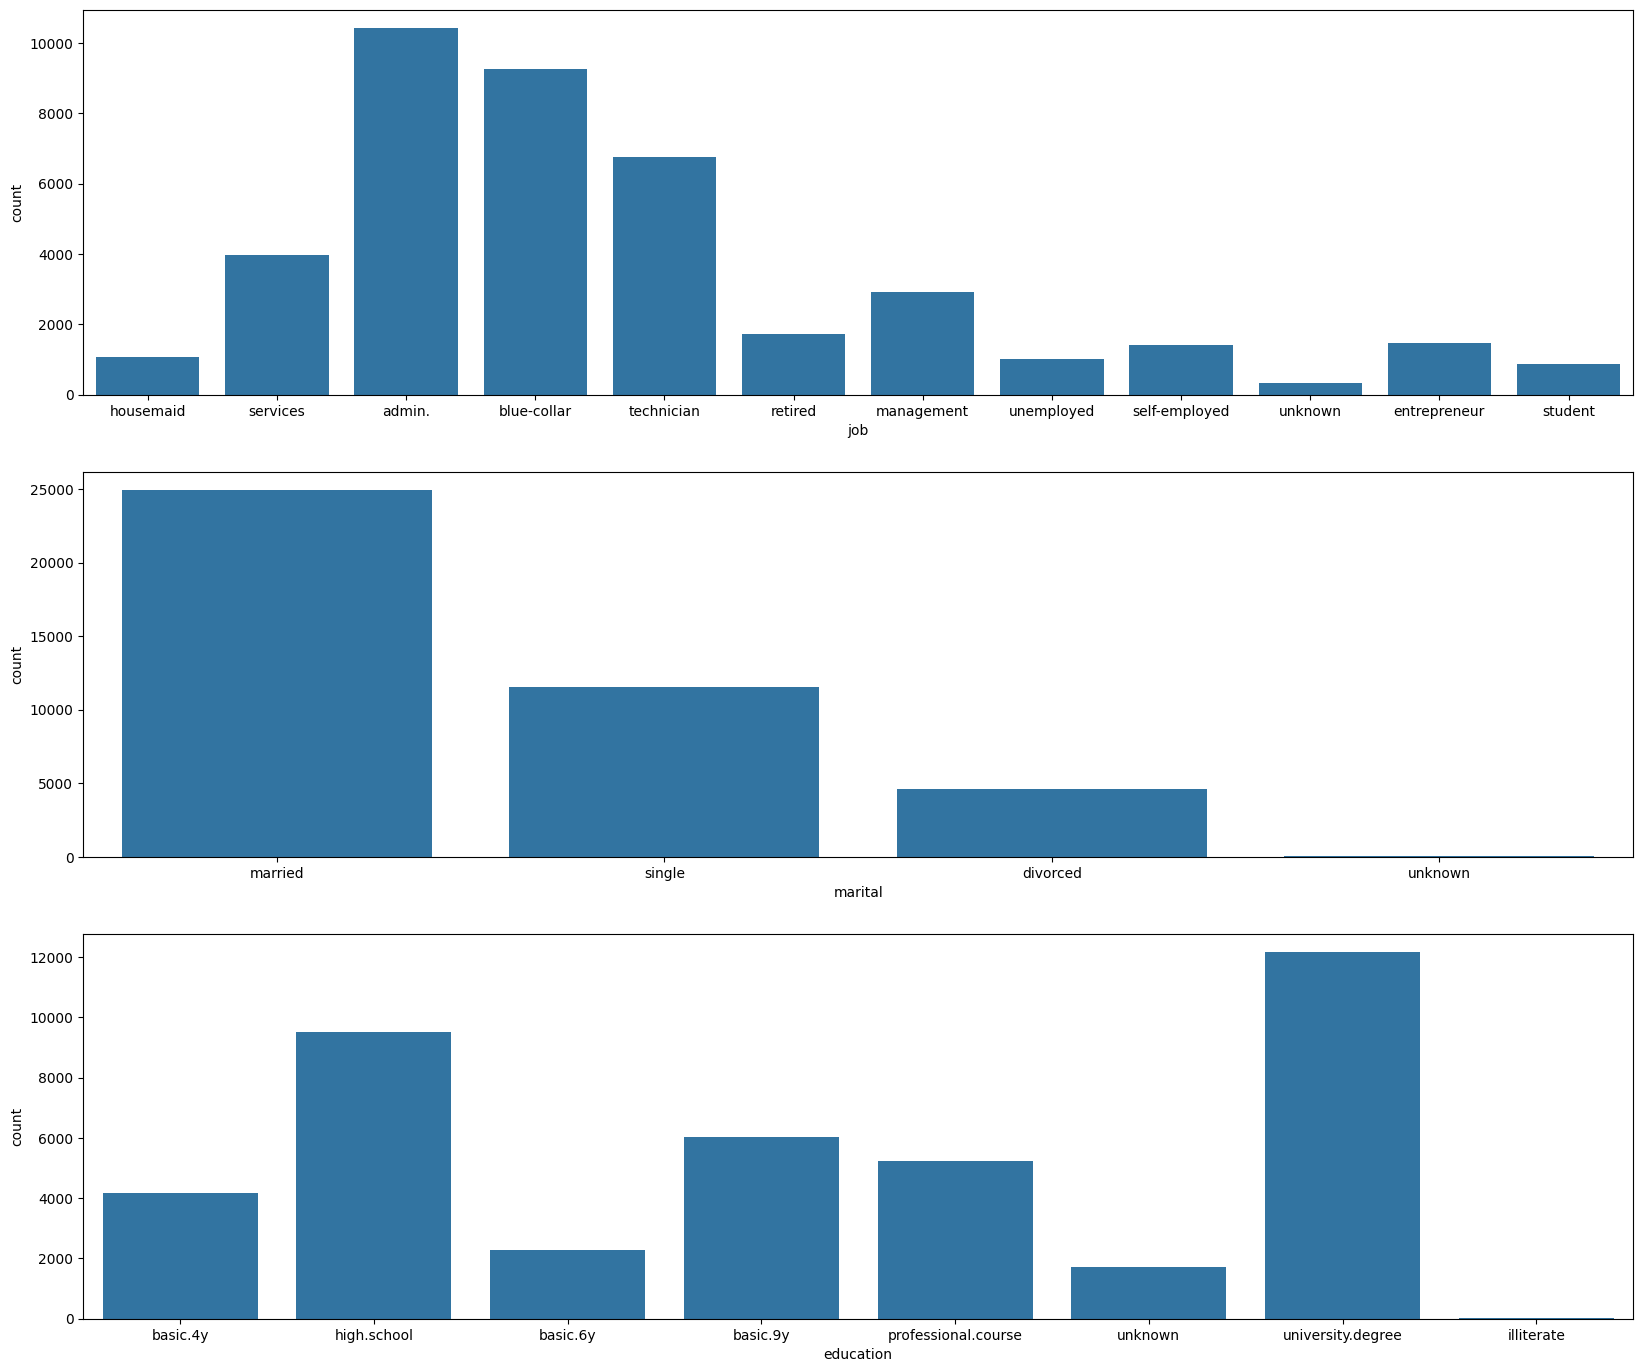

In [44]:
fig, axs = plt.subplots(3, 1, figsize=(20, 17))

sns.countplot(x='job', data=clients, ax=axs[0])
sns.countplot(x='marital', data=clients, ax=axs[1])
sns.countplot(x='education', data=clients, ax=axs[2])

**Висновки з завдання 6 (детальні)**

1. З графіків можемо зробити наступні висновки: більшість клінєтів одружені, найпопулярніші роботи: admin, blue-collar, technician. І також більшість мають university.degree

**Завдання 7** Аналіз атрибутів `default`, `housing` та `loan`:  
- Побудувати графіки розподілу даних по цим змінним.

<Axes: xlabel='loan', ylabel='count'>

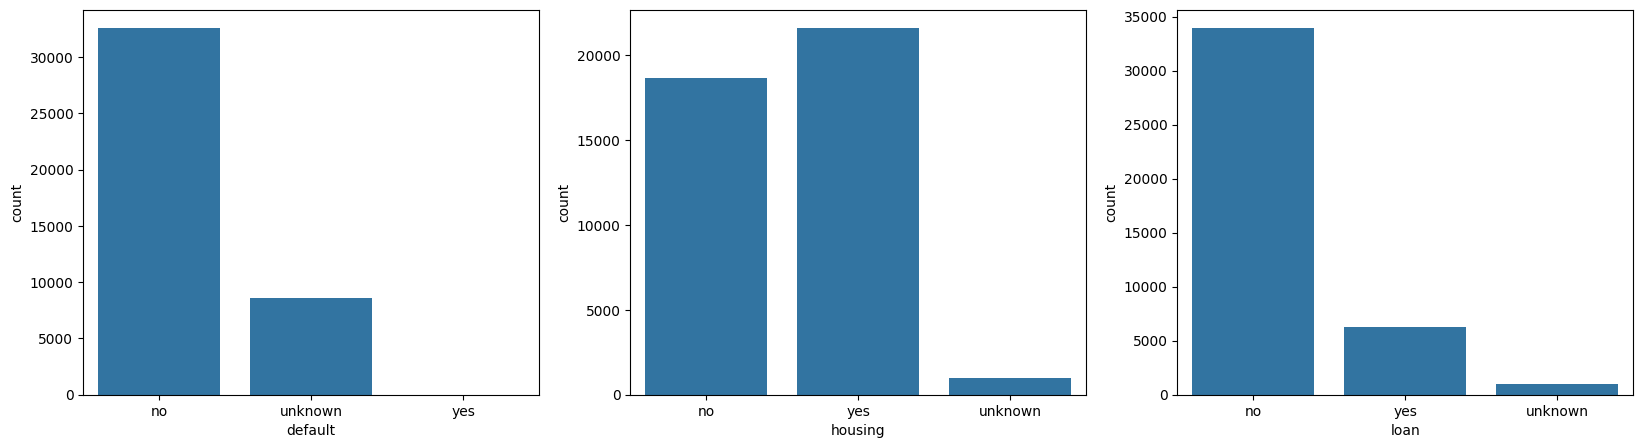

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

sns.countplot(x='default', data=clients, ax=axs[0])
sns.countplot(x='housing', data=clients, ax=axs[1])
sns.countplot(x='loan', data=clients, ax=axs[2])

**Завдання 8** Змінні **Jobs, Marital, Education, Default, Housing, Loan** трансформувати в неперервні змінні:

In [57]:
def encode_categorical_columns(df: pd.DataFrame, categorical_cols: list) -> pd.DataFrame:
    """
    Function for encoding categorical features using LabelEncoder

    df: pd.DataFrame to encode
    categorical_cols: specified columns to encode

    returns: pd.DataFrame with encoded values
    """
    for col in categorical_cols:
        le = LabelEncoder()
        not_null = df[col][df[col].notnull()]
        df.loc[df[col].notnull(), col] = le.fit_transform(not_null)

    return df

In [56]:
clients = encode_categorical_columns(clients, ['job', 'marital', 'education', 'default', 'housing', 'loan'])

**Завдання 9** Трансфомувати змінну **Age** (використовуючи її квартильні значення):




In [245]:
def encode_age(dataframe: pd.DataFrame, age_col: str ) -> pd.DataFrame:
    """
    Function for encoding age column

    df: pd.DataFrame to encode
    age_col: age col to encode
    """
    clients[age_col] = pd.qcut(clients[age_col], 4, labels=range(4), duplicates="drop")

    return dataframe

In [246]:
clients = encode_age(clients, "age")
clients.head()

,age,job,marital,education,default,loan,housing
0,3,housemaid,married,basic.4y,no,no,no
1,3,services,married,high.school,unknown,no,no
2,1,services,married,high.school,no,no,yes
3,2,admin.,married,basic.6y,no,no,no
4,3,services,married,high.school,no,yes,no


**Висновки з завдання 9 (детальні)** перевірити як відбулося перетворення змінних

In [247]:
clients["age"].unique()

[3, 1, 2, 0]
Categories (4, int64): [0 < 1 < 2 < 3]

In [248]:
np.quantile(clients["age"], [0, 0.25, 0.5, 0.75, 1])

array([0., 0., 1., 2., 3.])

<Axes: xlabel='age', ylabel='count'>

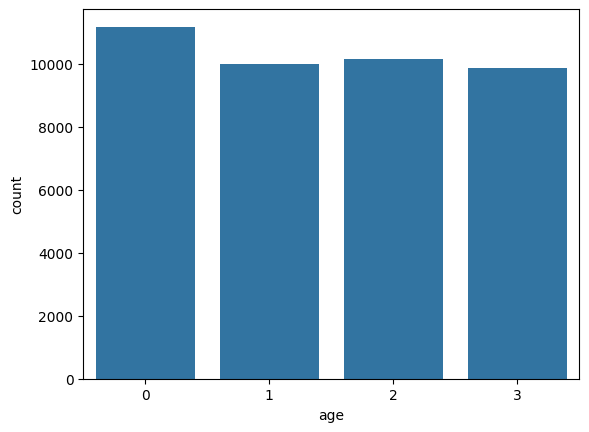

In [250]:
sns.countplot(data = clients, x = 'age')

## Вибірка містить певну кількість атрибутів, які характеризують останій зв'язок кліентів з банком

**Завдання 10** Виділити в окремий датафрейм змінні, які характеризують зв'язок клієнтів з банком;
- вивести цей датафрейм;
- перевірити ці змінні на `NaN`.

In [76]:
bank_relat = df[["contact", "month", "day_of_week", "duration"]]
bank_relat.head()

,contact,month,day_of_week,duration
0,telephone,may,mon,261
1,telephone,may,mon,149
2,telephone,may,mon,226
3,telephone,may,mon,151
4,telephone,may,mon,307


**Завдання 11** вивести унікальні значення, які містять атрибути `contact`, `month`, `day_of_week`

In [77]:
bank_relat["contact"].unique()

array(['telephone', 'cellular'], dtype=object)

In [78]:
bank_relat["month"].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr',
       'sep'], dtype=object)

In [79]:
bank_relat["day_of_week"].unique()

array(['mon', 'tue', 'wed', 'thu', 'fri'], dtype=object)

# Провести аналіз змінної **Duration**

змінна ` duration` містить інформацію про тривалість останнього дзвінка, в секундах (числова). Важливе зауваження: цей атрибут сильно впливає на цільову змінну (наприклад, якщо тривалість = 0, тоді y = "ні"). Проте тривалість невідома до здійснення дзвінка. Крім того, після закінчення дзвінка y, очевидно, відомо. Таким чином, цей внесок слід включати лише для цілей порівняльних показників і відкидати, якщо метою є реалістична модель прогнозування.

**Завдання 12** Аналіз атрибуту `duration`:  

Провести візуальний аналіз зміної `duration`:  


*   побудувати  `boxplot` та `distplot`;
*   перевірити розподіл по змінній `duration` на важкі хвости.



<Axes: xlabel='duration', ylabel='Density'>

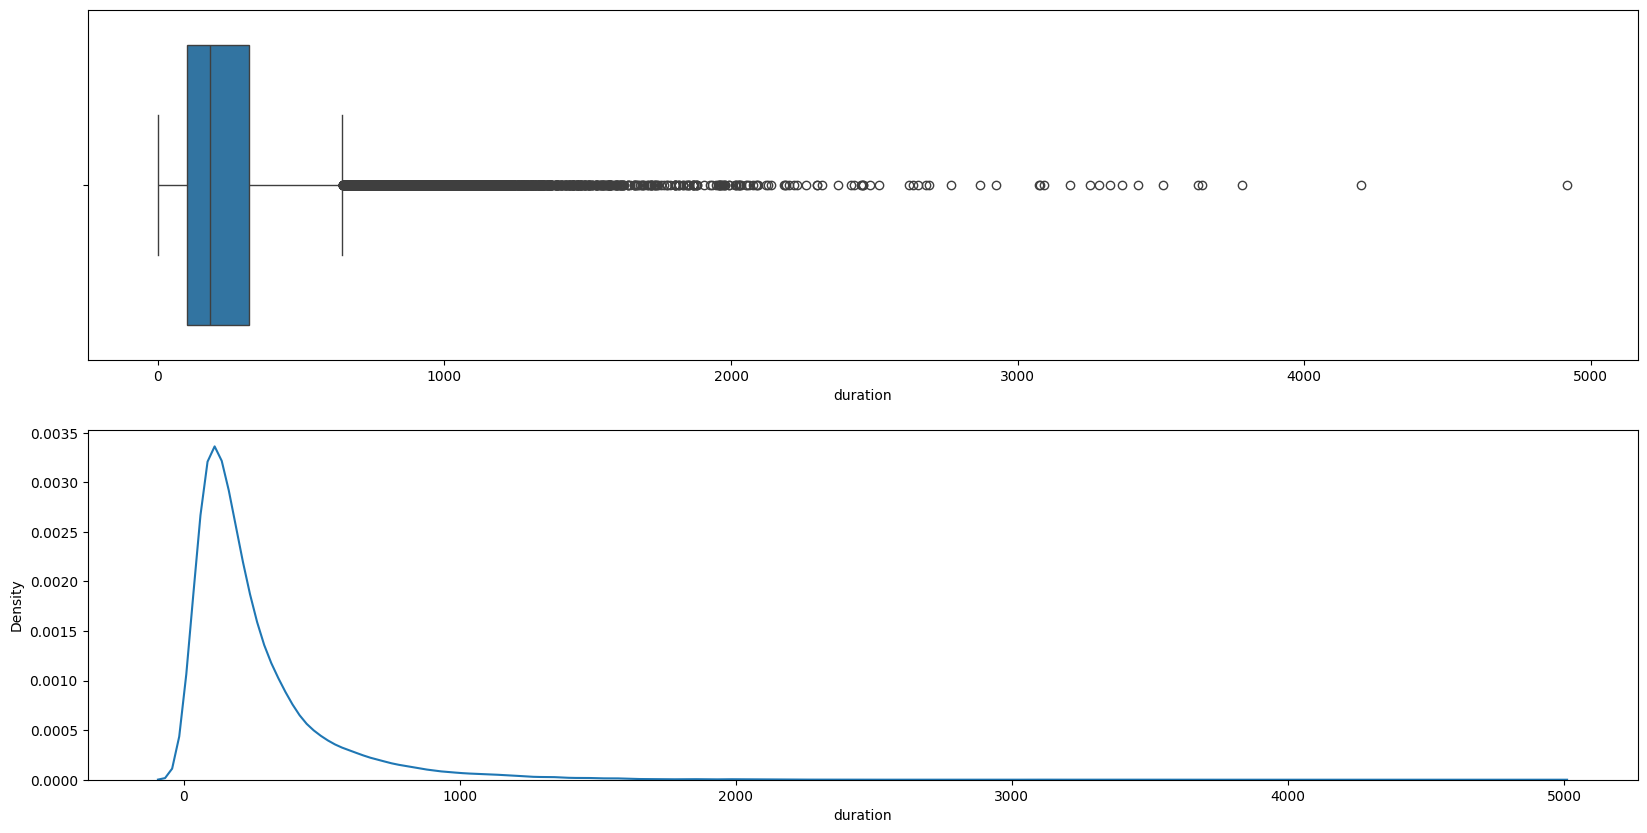

In [81]:
fig, axs = plt.subplots(2, 1, figsize=(20, 10))

sns.boxplot(data=bank_relat, x='duration', ax=axs[0])
sns.kdeplot(bank_relat['duration'], ax=axs[1])

**Завдання 13** Закодувати змінні Contact, Month, Day of Week (використовуйте функцію `encode_categorical_columns()`)

In [83]:
bank_relat = encode_categorical_columns(bank_relat, ["contact", "month", "day_of_week"])

**Завдання 14** Трансфомувати змінну **duration**, використовуючи її квартильні значення:

In [86]:
def encode_duration(dataframe: pd.DataFrame, duration_col: str ) -> pd.DataFrame:
  """
  Function for encoding duration column

  df: pd.DataFrame to encode
  duration_col: duration col to encode
  """

  dataframe[duration_col] = pd.qcut(dataframe[duration_col], q=4, labels=[0, 1, 2, 3])

  return dataframe

In [87]:
bank_relat = encode_duration(bank_relat, 'duration')

In [219]:
np.quantile(bank_relat['duration'], [0, 0.25, 0.5, 0.75, 1])

array([0., 0., 1., 2., 3.])

In [220]:
bank_relat.head()

,contact,month,day_of_week,duration
0,1,6,1,2
1,1,6,1,1
2,1,6,1,2
3,1,6,1,1
4,1,6,1,2


## Провести аналіз атрибутів **соціального та економічного контексту**

**Завдання 15** Виділити в окремий датафрейм атрибути соціального та єкономічного контексту

In [222]:
bank_socec = df[["emp.var.rate", "cons.price.idx", "nr.employed", "cons.conf.idx", "euribor3m",]]
bank_socec.head()

,emp.var.rate,cons.price.idx,nr.employed,cons.conf.idx,euribor3m
0,1.1,93.994,5191.0,-36.4,4.857
1,1.1,93.994,5191.0,-36.4,4.857
2,1.1,93.994,5191.0,-36.4,4.857
3,1.1,93.994,5191.0,-36.4,4.857
4,1.1,93.994,5191.0,-36.4,4.857


**Завдання 16** Виділити в окремий датафрейм всі інші атрибути атрибути - `campaign`, `pdays`,`previous`, `poutcome`

In [92]:
bank_other = df[["campaign", "pdays", "previous", "poutcome"]]
bank_other.head()

,campaign,pdays,previous,poutcome
0,1,999,0,nonexistent
1,1,999,0,nonexistent
2,1,999,0,nonexistent
3,1,999,0,nonexistent
4,1,999,0,nonexistent


**Завдання 17** Провести трансформацію атрибуту `poutcome`

<Axes: xlabel='poutcome', ylabel='count'>

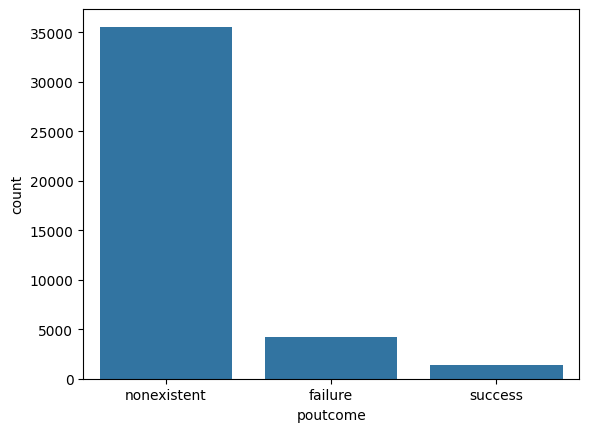

In [96]:
sns.countplot(x="poutcome", data=bank_other)

In [98]:
bank_other = encode_categorical_columns(bank_other, ["poutcome"])
bank_other.head()

,campaign,pdays,previous,poutcome
0,1,999,0,1
1,1,999,0,1
2,1,999,0,1
3,1,999,0,1
4,1,999,0,1


## Будування моделей класифікації

**Завдання 18** З'єднати всі отримані блоки в один датафрейм і перевірити, що він містить тільки потрібні для моделювання колонки

In [103]:
bank_final = pd.concat([clients, bank_relat, bank_socec, bank_other], axis = 1)
bank_final.head()

,age,job,marital,education,default,loan,housing,contact,month,day_of_week,duration,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,campaign,pdays,previous,poutcome
0,56,3,1,0,0,0,0,1,6,1,2,1.1,93.994,-36.4,4.857,1,999,0,1
1,57,7,1,3,1,0,0,1,6,1,1,1.1,93.994,-36.4,4.857,1,999,0,1
2,37,7,1,3,0,0,2,1,6,1,2,1.1,93.994,-36.4,4.857,1,999,0,1
3,40,0,1,1,0,0,0,1,6,1,1,1.1,93.994,-36.4,4.857,1,999,0,1
4,56,7,1,3,0,2,0,1,6,1,2,1.1,93.994,-36.4,4.857,1,999,0,1


**Завдання 19** Провести ділення вибірки

In [224]:
def prepare_data_for_training(X: pd.DataFrame,
                              target: pd.Series,
                              test_size: float,
                              n_splits: int,
                              random_state: int):
    """
    Function that prepares data for training. Splits the data into train and test datasets and get k-folds for cross-validation

    X: pd.DataFrame with features
    target: target pd.Series
    test_size: the size of test datasets
    n_splits: number of cross-validation splits
    random_state: random state to reproduce the same split

    returns: X_train, X_test, y_train, y_test, k_fold
    """

    X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=test_size, random_state=random_state, shuffle=True)
    k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    return X_train, X_test, y_train, y_test, k_fold

In [225]:
X_train, X_test, y_train, y_test, k_fold = prepare_data_for_training(bank_final, bank_target, 0.2, 10, 101)

In [226]:
def scale_the_data(X_train: pd.DataFrame,
                   X_test: pd.DataFrame):

  sc_X = StandardScaler()
  X_train = sc_X.fit_transform(X_train)
  X_test = sc_X.transform(X_test)

  return X_train, X_test

In [185]:
X_train, X_test = scale_the_data(X_train, X_test)

## Логістична Регресія

In [232]:
logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)
logpred = logmodel.predict(X_test)


print(confusion_matrix(y_test, logpred))
print(round(accuracy_score(y_test, logpred),2)*100)
LOGCV = (cross_val_score(logmodel, X_test, y_test, cv=k_fold, n_jobs=1, scoring = 'accuracy').mean())

[[ 645  165   16]
 [   0 7158    0]
 [   7    0  247]]
98.0


## k-NN

k=1 92.48 (+/- 0.45)
k=2 91.25 (+/- 0.50)
k=3 93.07 (+/- 0.45)
k=4 93.27 (+/- 0.37)
k=5 93.10 (+/- 0.46)
k=6 93.52 (+/- 0.49)
k=7 92.85 (+/- 0.46)
k=8 93.36 (+/- 0.39)
k=9 92.57 (+/- 0.48)
k=10 93.12 (+/- 0.45)
k=11 92.39 (+/- 0.46)
k=12 92.89 (+/- 0.44)
k=13 92.27 (+/- 0.50)
k=14 92.73 (+/- 0.44)
k=15 92.02 (+/- 0.40)
k=16 92.49 (+/- 0.40)
k=17 91.88 (+/- 0.46)
k=18 92.31 (+/- 0.40)
k=19 91.74 (+/- 0.50)
k=20 92.10 (+/- 0.45)
k=21 91.53 (+/- 0.51)
k=22 91.90 (+/- 0.56)
k=23 91.35 (+/- 0.54)
k=24 91.69 (+/- 0.54)
k=25 91.21 (+/- 0.53)
The optimal number of neighbors is 5 with 93.5%


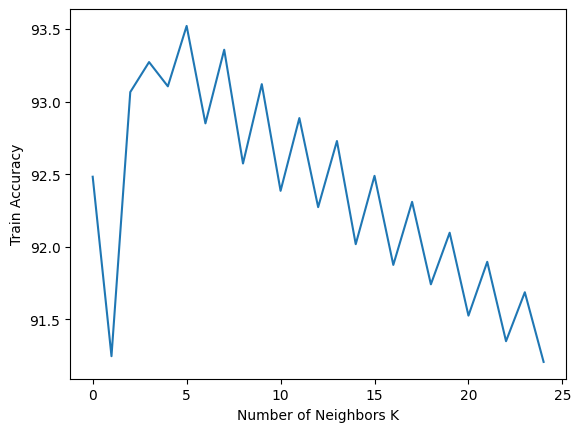

In [233]:
#Neighbors
neighbors = np.arange(0,25)

#Create empty list that will hold cv scores
cv_scores = []

#Perform 10-fold cross validation on training set for odd values of k:
for k in neighbors:
    k_value = k+1
    knn = KNeighborsClassifier(n_neighbors = k_value, weights='uniform', p=2, metric='euclidean')
    scores = model_selection.cross_val_score(knn, X_train, y_train, cv=k_fold, scoring='accuracy')
    cv_scores.append(scores.mean()*100)
    print("k=%d %0.2f (+/- %0.2f)" % (k_value, scores.mean()*100, scores.std()*100))

optimal_k = neighbors[cv_scores.index(max(cv_scores))]
print ("The optimal number of neighbors is %d with %0.1f%%" % (optimal_k, cv_scores[optimal_k]))

plt.plot(neighbors, cv_scores)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Train Accuracy')
plt.show()

In [234]:
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
knnpred = knn.predict(X_test)

print(confusion_matrix(y_test, knnpred))
print(round(accuracy_score(y_test, knnpred),2)*100)
KNNCV = (cross_val_score(knn, X_test, y_test, cv=k_fold, n_jobs=1, scoring = 'accuracy').mean())

[[ 331  465   30]
 [  62 7096    0]
 [   1    0  253]]
93.0


## Логістична Регресія

In [235]:
models = pd.DataFrame({
                'Models': ['LOGCV', 'KNNCV'],
                'Score':  [LOGCV, KNNCV]})

models.sort_values(by='Score', ascending=False)

,Models,Score
0,LOGCV,0.989441
1,KNNCV,0.917211


**Висновки по моделям (детальні)**

Середня точність моделі приблизно 98%
KNN поступається логістичній регресії, хоча показав також високу точність